<a href="https://colab.research.google.com/github/minjeon99/ESAA-10th-OB/blob/Week13/w13_fri_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **딥 러닝 파이토치 교과서**

## **ch2. [기초] - 파이토치 기초(PyTorch Basic)**

### **01 파이토치 패키지의 기본 구성**
1. `torch`: 메인 네임스페이스
  - 텐서 등의 다양한 수학 함수 포함
  - Numpy와 유사한 구조
2. `torch.autograd `: 자동 미분을 위한 함수들 포함
  - 자동 미분의 on/off를 제어하는 콘텍스트 매니저(enable_grad/no_grad)
  - 자체 미분 가능 함수를 정의할 때 사용하는 기반 클래스 `Function` 등
3. `torch.nn`: 신경망을 구축하기 위한 다양한 데이터 구조나 레이어 등
  - RNN, LSTM 등의 레이어
  - ReLU와 같은 활성화 함수
  - MSELoss와 같은 손실 함수
4. `torch.optim`: 확률적 경사 하강법(Stochastic Gradient Descent, SGD)를 중심으로 한 파라미터 최적화 알고리즘 구현
5. `torch.utils.data`: SGD의 반복 연산을 실행할 때 사용하는 미니 배치용 유틸리티 함수
6. `torch.onnx`: OXX(Open Neural Network Exchange) 포맷으로 모델을 export할 때 사용
  - ONNX: 서로 다른 딥러닝 프레임워크 간에 모델 공유할 때 사용

### **02 텐서 조작하기 (Tensor Manipulation)**

#### 1. 벡터, 행렬, 텐서(Vector, Matrix, Tensor)
- 스칼라: 차원이 없는 값
- 벡터(Vector): 1차원으로 구성된 값 = 1d-tensor
- 행렬(Matrix): 2차원으로 구성된 값 = 2d-tensor
- 텐서(Tensor): 3차원 이상으로 구성된 값

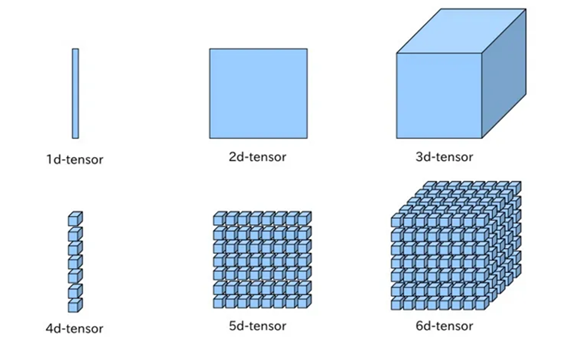

**2D Tensor(Typical Simple Setting)**
- |t| = (Batch size, dim)

  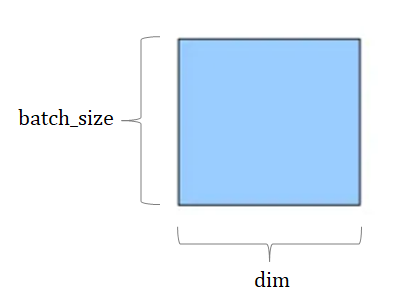

**3D Tensor(Typical Computer Vision)**: 비전 분야에서의 3차원 텐서
- |t| = (batch size, width, height)

  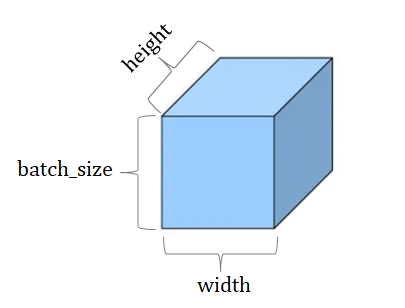

**3D Tensor(Typical Natural Language Processing)**: NLP 분야에서의 3차원 텐서
- |t| = (batch size, length, dim)

  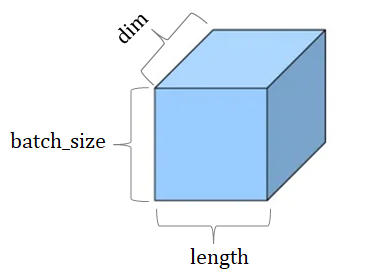

**NLP 분야의 3D 텐서 예제**
- 전체 훈련 데이터

  ```
  [[나는 사과를 좋아해], [나는 바나나를 좋아해], [나는 사과를 싫어해], [나는 바나나를 싫어해]]
  ```
- 단어별로 나누기(토큰화) → 4X3 크기의 2D 텐서

  ```
  [['나는', '사과를', '좋아해'], ['나는', '바나나를', '좋아해'], ['나는', '사과를', '싫어해'], ['나는', '바나나를', '싫어해']]
  ```
- 벡터화(예) → 4X3X3 크기의 3D 텐서

  ```
  '나는' = [0.1, 0.2, 0.9]
  '사과를' = [0.3, 0.5, 0.1]
  '바나나를' = [0.3, 0.5, 0.2]
  '좋아해' = [0.7, 0.6, 0.5]
  '싫어해' = [0.5, 0.6, 0.7]

  [[[0.1, 0.2, 0.9], [0.3, 0.5, 0.1], [0.7, 0.6, 0.5]],
 [[0.1, 0.2, 0.9], [0.3, 0.5, 0.2], [0.7, 0.6, 0.5]],
 [[0.1, 0.2, 0.9], [0.3, 0.5, 0.1], [0.5, 0.6, 0.7]],
 [[0.1, 0.2, 0.9], [0.3, 0.5, 0.2], [0.5, 0.6, 0.7]]]

  ```
- batch size=2 설정

  ```
  첫번째 배치 #1
  [[[0.1, 0.2, 0.9], [0.3, 0.5, 0.1], [0.7, 0.6, 0.5]],
  [[0.1, 0.2, 0.9], [0.3, 0.5, 0.2], [0.7, 0.6, 0.5]]]

  두번째 배치 #2
  [[[0.1, 0.2, 0.9], [0.3, 0.5, 0.1], [0.5, 0.6, 0.7]],
  [[0.1, 0.2, 0.9], [0.3, 0.5, 0.2], [0.5, 0.6, 0.7]]]

  ```

#### 2. 넘파이로 텐서 만들기(벡터와 행렬 만들기)

**Numpy 기초 이해하기**

In [1]:
import numpy as np

In [2]:
t = np.array([0., 1., 2., 3., 4., 5., 6.])
print(t)

[0. 1. 2. 3. 4. 5. 6.]


In [3]:
print('Rank of t: ', t.ndim)
print('Shape of t: ', t.shape)

Rank of t:  1
Shape of t:  (7,)


- 인덱스

In [4]:
print('t[0] t[1] t[-1] = ', t[0], t[1], t[-1])

t[0] t[1] t[-1] =  0.0 1.0 6.0


- 슬라이싱

In [5]:
print('t[2:5] t[4:-1]  = ', t[2:5], t[4:-1])

t[2:5] t[4:-1]  =  [2. 3. 4.] [4. 5.]


In [6]:
print('t[:2] t[3:]     = ', t[:2], t[3:])

t[:2] t[3:]     =  [0. 1.] [3. 4. 5. 6.]


**2D with Numpy**

In [7]:
t = np.array([[1., 2., 3.], [4., 5., 6.], [7., 8., 9.], [10., 11., 12.]])
print(t)

[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]


In [8]:
print('Rank  of t: ', t.ndim)
print('Shape of t: ', t.shape)

Rank  of t:  2
Shape of t:  (4, 3)


#### 3. 파이토치 텐서 선언하기(PyTorch Tensor Allocation)

In [9]:
import torch

**1D with PyTorch**

In [10]:
t = torch.FloatTensor([0., 1., 2., 3., 4., 5., 6.])
print(t)

tensor([0., 1., 2., 3., 4., 5., 6.])


In [11]:
print(t.dim())
print(t.shape)
print(t.size())

1
torch.Size([7])
torch.Size([7])


In [12]:
print(t[0], t[1], t[-1])
print(t[2:5], t[4:-1])
print(t[:2], t[3:])

tensor(0.) tensor(1.) tensor(6.)
tensor([2., 3., 4.]) tensor([4., 5.])
tensor([0., 1.]) tensor([3., 4., 5., 6.])


**2D with PyTorch**

In [13]:
t = torch.FloatTensor([[1., 2., 3.],
                       [4., 5., 6.],
                       [7., 8., 9.],
                       [10., 11., 12.]
                      ])
print(t)

tensor([[ 1.,  2.,  3.],
        [ 4.,  5.,  6.],
        [ 7.,  8.,  9.],
        [10., 11., 12.]])


In [14]:
print(t.dim())
print(t.size())

2
torch.Size([4, 3])


In [16]:
print(t[:, 1])
print(t[:, 1].size())

tensor([ 2.,  5.,  8., 11.])
torch.Size([4])


In [17]:
print(t[:, :-1])

tensor([[ 1.,  2.],
        [ 4.,  5.],
        [ 7.,  8.],
        [10., 11.]])


**브로드캐스팅(Broadcasting)**

In [18]:
m1 = torch.FloatTensor([[3, 3]])
m2 = torch.FloatTensor([[2, 2]])
print(m1 + m2)

tensor([[5., 5.]])


In [19]:
# Vector + scalar
m1 = torch.FloatTensor([[1, 2]])
m2 = torch.FloatTensor([3])
print(m1 + m2)

tensor([[4., 5.]])


In [20]:
# 2 x 1 Vector + 1 x 2 Vector
m1 = torch.FloatTensor([[1, 2]])
m2 = torch.FloatTensor([[3], [4]])
print(m1 + m2)

tensor([[4., 5.],
        [5., 6.]])


```
# 브로드캐스팅 과정에서 두 텐서의 변경 과정
[1, 2]
==> [[1, 2],
     [1, 2]]
[3]
[4]
==> [[3, 3],
     [4, 4]]
```

**행렬 곱셈과 곱셈의 차이(Matrix Multiplication Vs. Multiplication)**
- `matmul()`: 행렬 곱셈

In [21]:
m1 = torch.FloatTensor([[1, 2], [3, 4]])
m2 = torch.FloatTensor([[1], [2]])
print('Shape of Matrix 1: ', m1.shape) # 2 x 2
print('Shape of Matrix 2: ', m2.shape) # 2 x 1
print(m1.matmul(m2)) # 2 x 1

Shape of Matrix 1:  torch.Size([2, 2])
Shape of Matrix 2:  torch.Size([2, 1])
tensor([[ 5.],
        [11.]])


- element-wise 곱셈: 동일한 위치에 있는 원소끼리의 곱
  - `*`, `mul()`

In [22]:
m1 = torch.FloatTensor([[1, 2], [3, 4]])
m2 = torch.FloatTensor([[1], [2]])
print('Shape of Matrix 1: ', m1.shape) # 2 x 2
print('Shape of Matrix 2: ', m2.shape) # 2 x 1
print(m1 * m2) # 2 x 2
print(m1.mul(m2))

Shape of Matrix 1:  torch.Size([2, 2])
Shape of Matrix 2:  torch.Size([2, 1])
tensor([[1., 2.],
        [6., 8.]])
tensor([[1., 2.],
        [6., 8.]])


**평균(Mean)**

In [23]:
t = torch.FloatTensor([1, 2])
print(t.mean())

tensor(1.5000)


In [24]:
t = torch.FloatTensor([[1, 2], [3, 4]])
print(t)

tensor([[1., 2.],
        [3., 4.]])


In [25]:
print(t.mean())

tensor(2.5000)


- 4개 원소의 평균값

In [26]:
print(t.mean(dim=0))

tensor([2., 3.])


- 첫 번째 차원으로 설정 → 열의 차원만 보존하면서 평균 계산

```
# 실제 연산 과정
t.mean(dim=0)은 입력에서 첫번째 차원을 제거한다.

[[1., 2.],
 [3., 4.]]

1과 3의 평균을 구하고, 2와 4의 평균을 구한다.
결과 ==> [2., 3.]
```

In [27]:
print(t.mean(dim=1))

tensor([1.5000, 3.5000])


In [28]:
print(t.mean(dim=-1))

tensor([1.5000, 3.5000])


**덧셈(Sum)**

In [29]:
t = torch.FloatTensor([[1, 2], [3, 4]])
print(t)

tensor([[1., 2.],
        [3., 4.]])


In [30]:
print(t.sum()) # 단순히 원소 전체의 덧셈을 수행
print(t.sum(dim=0)) # 행을 제거
print(t.sum(dim=1)) # 열을 제거
print(t.sum(dim=-1)) # 열을 제거

tensor(10.)
tensor([4., 6.])
tensor([3., 7.])
tensor([3., 7.])


**최대(Max)와 아그맥스(ArgMax)**

In [31]:
t = torch.FloatTensor([[1, 2], [3, 4]])
print(t)

tensor([[1., 2.],
        [3., 4.]])


In [32]:
print(t.max())

tensor(4.)


In [33]:
print(t.max(dim=0))

torch.return_types.max(
values=tensor([3., 4.]),
indices=tensor([1, 1]))


- max에 dim 인자를 주면 argmax도 함께 return

In [34]:
print('Max: ', t.max(dim=0)[0])
print('Argmax: ', t.max(dim=0)[1])

Max:  tensor([3., 4.])
Argmax:  tensor([1, 1])


In [35]:
print(t.max(dim=1))
print(t.max(dim=-1))

torch.return_types.max(
values=tensor([2., 4.]),
indices=tensor([1, 1]))
torch.return_types.max(
values=tensor([2., 4.]),
indices=tensor([1, 1]))


**뷰(View) - 원소의 수를 유지하면서 텐서의 크기 변경⭐**
- numpy의 reshape와 같은 역할

In [36]:
t = np.array([[[0, 1, 2],
               [3, 4, 5]],
              [[6, 7, 8],
               [9, 10, 11]]])
ft = torch.FloatTensor(t)

In [37]:
print(ft.shape)

torch.Size([2, 2, 3])


- 3차원 텐서 → 2차원 텐서로 변경

In [38]:
print(ft.view([-1, 3])) # ft라는 텐서를 (?, 3)의 크기로 변경
print(ft.view([-1, 3]).shape)

tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.]])
torch.Size([4, 3])


📍 view는 기본적으로 변경 전과 변경 후의 텐서 안의 원소의 개수가 유지

📍 파이토치의 view는 사이즈가 -1로 설정되면 다른 차원으로부터 해당 값을 유추

- 3차원 텐서의 크기 변경

In [39]:
print(ft.view([-1, 1, 3]))
print(ft.view([-1, 1, 3]).shape)

tensor([[[ 0.,  1.,  2.]],

        [[ 3.,  4.,  5.]],

        [[ 6.,  7.,  8.]],

        [[ 9., 10., 11.]]])
torch.Size([4, 1, 3])


**스퀴즈(Squeeze) - 1인 차원을 제거**

In [40]:
ft = torch.FloatTensor([[0], [1], [2]])
print(ft)
print(ft.shape)

tensor([[0.],
        [1.],
        [2.]])
torch.Size([3, 1])


In [41]:
print(ft.squeeze())
print(ft.squeeze().shape)

tensor([0., 1., 2.])
torch.Size([3])


**언스퀴즈(Unsqueeze) - 특정 위치에 1인 차원을 추가**

In [42]:
ft = torch.Tensor([0, 1, 2])
print(ft.shape)

torch.Size([3])


In [43]:
print(ft.unsqueeze(0)) # 첫번째 차원
print(ft.unsqueeze(0).shape)

tensor([[0., 1., 2.]])
torch.Size([1, 3])


In [44]:
print(ft.view(1, -1))
print(ft.view(1, -1).shape)

tensor([[0., 1., 2.]])
torch.Size([1, 3])


In [45]:
print(ft.unsqueeze(1))
print(ft.unsqueeze(1).shape)

tensor([[0.],
        [1.],
        [2.]])
torch.Size([3, 1])


In [46]:
print(ft.unsqueeze(-1))
print(ft.unsqueeze(-1).shape)

tensor([[0.],
        [1.],
        [2.]])
torch.Size([3, 1])


**타입 캐스팅(Type Casting)**: 자료형 변환

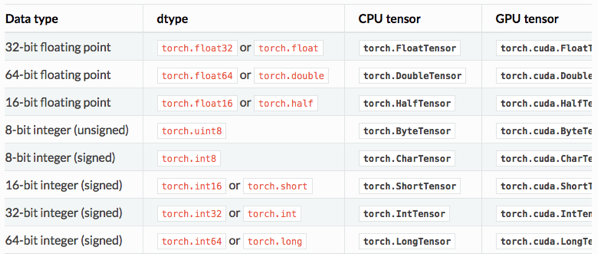

In [47]:
lt = torch.LongTensor([1, 2, 3, 4]) # long 타입의 텐서
print(lt)

tensor([1, 2, 3, 4])


In [48]:
print(lt.float()) # float형으로 변환

tensor([1., 2., 3., 4.])


In [49]:
bt = torch.ByteTensor([True, False, False, True]) # Byte 타입
print(bt)

tensor([1, 0, 0, 1], dtype=torch.uint8)


In [50]:
print(bt.long()) # long type
print(bt.float()) # float type

tensor([1, 0, 0, 1])
tensor([1., 0., 0., 1.])


**연결하기(concatenate)**

In [51]:
x = torch.FloatTensor([[1, 2], [3, 4]])
y = torch.FloatTensor([[5, 6], [7, 8]])

In [52]:
print(torch.cat([x, y], dim=0))

tensor([[1., 2.],
        [3., 4.],
        [5., 6.],
        [7., 8.]])


In [53]:
print(torch.cat([x, y], dim=1))

tensor([[1., 2., 5., 6.],
        [3., 4., 7., 8.]])


**스택킹(Stacking)**

In [54]:
x = torch.FloatTensor([1, 4])
y = torch.FloatTensor([2, 5])
z = torch.FloatTensor([3, 6])

In [55]:
print(torch.stack([x, y, z]))

tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])


- stacking은 많은 연산을 축약하고 있음
- 아래 코드와 동일한 작업

In [56]:
print(torch.cat([x.unsqueeze(0), y.unsqueeze(0), z.unsqueeze(0)], dim=0))

tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])


In [57]:
print(torch.stack([x, y, z], dim=1))

tensor([[1., 2., 3.],
        [4., 5., 6.]])


**ones_like와 zeros_like - 0으로 채워진 텐서와 1로 채워진 텐서**

In [58]:
x = torch.FloatTensor([[0, 1, 2], [2, 1, 0]])
print(x)

tensor([[0., 1., 2.],
        [2., 1., 0.]])


In [59]:
print(torch.ones_like(x)) # 입력 텐서와 동일한 크기 & 값은 1로 채우기

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [60]:
print(torch.zeros_like(x)) # 입력 텐서와 동일한 크기 & 값은 0으로 채우기

tensor([[0., 0., 0.],
        [0., 0., 0.]])


**In-place Operation (덮어쓰기 연산)**

In [61]:
x = torch.FloatTensor([[1, 2], [3, 4]])

In [62]:
print(x.mul(2.))
print(x)

tensor([[2., 4.],
        [6., 8.]])
tensor([[1., 2.],
        [3., 4.]])


In [63]:
print(x.mul_(2.)) # 곱하기 2를 수행 → 변수 x에 값 저장 & 결과 출력
print(x)

tensor([[2., 4.],
        [6., 8.]])
tensor([[2., 4.],
        [6., 8.]])


### **03 파이썬 클래스(class)**

#### 함수(function)과 클래스(Class)의 차이

**함수(function)로 덧셈기 구현**

In [64]:
result = 0 # 전역 변수

In [65]:
def add(num): # add 함수 구현
    global result
    result += num
    return result

In [66]:
print(add(3))
print(add(4))

3
7


**함수(function)로 두 개의 덧셈기 구현**
- 두 개의 계산기로 (3+7), (3+10)을 계산하고 싶은 것

In [67]:
result1 = 0
result2 = 0

def add1(num):
    global result1
    result1 += num
    return result1

def add2(num):
    global result2
    result2 += num
    return result2

print(add1(3))
print(add1(4))
print(add2(3))
print(add2(7))

3
7
3
10


**클래스(class)로 덧셈기 구현**

In [69]:
class Calculator:
    def __init__(self): # 생성자: 객체 생성 시 호출될 때 실행되는 초기화 함수
        self.result = 0

    def add(self, num): # 객체 생성 후 사용할 수 있는 함수.
        self.result += num
        return self.result

- 객체 생성

In [70]:
cal1 = Calculator()
cal2 = Calculator()

- 독립적인 덧셈 연산 수행

In [71]:
print(cal1.add(3))
print(cal1.add(4))
print(cal2.add(3))
print(cal2.add(7))

3
7
3
10


➡️ 함수보다 클래스로 별도의 객체를 생성하는 것이 더 간결

## **ch3. [ML 입문] 머신 러닝 입문하기(Machine Learning Basics)**

### **01 선형 회귀와 자동 미분(Linear Regression and Autograd)**

#### 1. 데이터에 대한 이해(Data Definition)
**훈련 데이터셋, 테스트 데이터셋**
- 훈련 데이터셋(training dataset): 예측을 위해 사용하는 데이터
- 테스트 데이터셋(test dataset): 학습이 끝난 후, 이 모델이 얼마나 잘 작동하는지 판별하는 데이터셋

In [72]:
x_train = torch.FloatTensor([[1], [2], [3]]) # 공부 시간
y_train = torch.FloatTensor([[2], [4], [6]]) # 점수

### 2. 가설(Hypothesis) 수립
- 선형 회귀의 가설(직선의 방정식): $y=Wx+b$
  - W: 가중치(weight)
  - b: 편향(bias)

### 3. 비용 함수(Cost function)
- 비용 함수(cost function) = 손실 함수(loss function) = 오차 함수(error function) = 목적 함수(objective function)
- 실제값과 예측값의 차이 = 실제값에서의 오차

  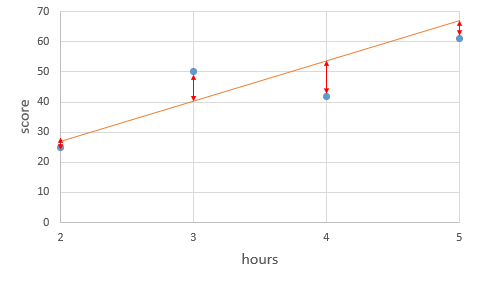
- 평균 제곱 오차를 W와 b에 의한 비용 함수(Cost function)로 재정의
$$cost(W,b)=\frac{1}{n}\sum^n_{i=1}[y^{(i)}-H(x^{(i)})]^2$$
- Cost(W,b)를 최소가 되게 만드는 W, b를 구하면 훈련 데이터를 가장 잘 나타내는 직선

#### 4. 옵티마이저 - 경사 하강법(Gradient Descent)
- 옵티마이저(Optimizer) 알고리즘 = 최적화 알고리즘
- 옵티마이저 알고리즘을 통해 적절한 W와 b를 찾아내는 과정 ➡️ 머신 러닝에서 학습(training)
- W와 cost의 관계 그래프

  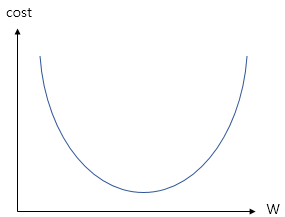
- 임의의 초기값 W값을 정한 뒤에, 맨 아래의 볼록한 부분을 향해 점차 W의 값을 수정 ➡️ 경사 하강법(Gradient Descent)

  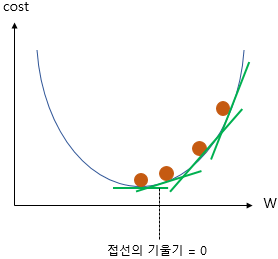
- cost가 최소화가 되는 지점 = 접선의 기울기가 0이 되는 지점 = 미분값이 0이 되는 지점

  ➡️ 비용 함수(Cost function) 미분하여 현재 W에서의 접선의 기울기 계산 → 접선의 기울기가 낮은 방향으로 W의 값 변경하는 작업을 반복
  $$gradient=\frac{∂cost(W)}{∂W}$$
- 기울기가 음수일 때: W의 값이 증가
- 기울기가 양수일 때: W의 값이 감소
  $$W:=W-α\frac{∂}{∂W}cost(W)$$
  - 학습률(learning rate) α: W를 변경할 때 얼마나 크게 변경할지 결정

#### 5. 파이토치로 선형 회귀 구현

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [74]:
torch.manual_seed(1)

**변수 선언**

In [75]:
x_train = torch.FloatTensor([[1], [2], [3]])
y_train = torch.FloatTensor([[2], [4], [6]])

In [76]:
print(x_train)
print(x_train.shape)

tensor([[1.],
        [2.],
        [3.]])
torch.Size([3, 1])


In [77]:
print(y_train)
print(y_train.shape)

tensor([[2.],
        [4.],
        [6.]])
torch.Size([3, 1])


**가중치와 편향 초기화**

In [78]:
W = torch.zeros(1, requires_grad=True)
print(W)

tensor([0.], requires_grad=True)


In [79]:
b = torch.zeros(1, requires_grad=True)
print(b)

tensor([0.], requires_grad=True)


**가설 설정**

In [80]:
hypothesis = x_train * W + b
print(hypothesis)

tensor([[0.],
        [0.],
        [0.]], grad_fn=<AddBackward0>)


**비용 함수 선언**

In [81]:
cost = torch.mean((hypothesis - y_train) ** 2)
print(cost)

tensor(18.6667, grad_fn=<MeanBackward0>)


**경사 하강법 구현**

In [82]:
optimizer = optim.SGD([W, b], lr=0.01)

In [83]:
optimizer.zero_grad()
cost.backward()
optimizer.step()

**전체 코드**

In [84]:
# 데이터
x_train = torch.FloatTensor([[1], [2], [3]])
y_train = torch.FloatTensor([[2], [4], [6]])
# 모델 초기화
W = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
# optimizer 설정
optimizer = optim.SGD([W, b], lr=0.01)

nb_epochs = 1999 # 원하는만큼 경사 하강법을 반복
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    hypothesis = x_train * W + b

    # cost 계산
    cost = torch.mean((hypothesis - y_train) ** 2)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} W: {:.3f}, b: {:.3f} Cost: {:.6f}'.format(
            epoch, nb_epochs, W.item(), b.item(), cost.item()
        ))

Epoch    0/1999 W: 0.187, b: 0.080 Cost: 18.666666
Epoch  100/1999 W: 1.746, b: 0.578 Cost: 0.048171
Epoch  200/1999 W: 1.800, b: 0.454 Cost: 0.029767
Epoch  300/1999 W: 1.843, b: 0.357 Cost: 0.018394
Epoch  400/1999 W: 1.876, b: 0.281 Cost: 0.011366
Epoch  500/1999 W: 1.903, b: 0.221 Cost: 0.007024
Epoch  600/1999 W: 1.924, b: 0.174 Cost: 0.004340
Epoch  700/1999 W: 1.940, b: 0.136 Cost: 0.002682
Epoch  800/1999 W: 1.953, b: 0.107 Cost: 0.001657
Epoch  900/1999 W: 1.963, b: 0.084 Cost: 0.001024
Epoch 1000/1999 W: 1.971, b: 0.066 Cost: 0.000633
Epoch 1100/1999 W: 1.977, b: 0.052 Cost: 0.000391
Epoch 1200/1999 W: 1.982, b: 0.041 Cost: 0.000242
Epoch 1300/1999 W: 1.986, b: 0.032 Cost: 0.000149
Epoch 1400/1999 W: 1.989, b: 0.025 Cost: 0.000092
Epoch 1500/1999 W: 1.991, b: 0.020 Cost: 0.000057
Epoch 1600/1999 W: 1.993, b: 0.016 Cost: 0.000035
Epoch 1700/1999 W: 1.995, b: 0.012 Cost: 0.000022
Epoch 1800/1999 W: 1.996, b: 0.010 Cost: 0.000013
Epoch 1900/1999 W: 1.997, b: 0.008 Cost: 0.000008

- 실제 정답인 2에 근접

**optimizer.zero_grad()가 필요한 이유**

In [85]:
import torch
w = torch.tensor(2.0, requires_grad=True)

nb_epochs = 20
for epoch in range(nb_epochs + 1):

  z = 2*w

  z.backward()
  print('수식을 w로 미분한 값 : {}'.format(w.grad))

수식을 w로 미분한 값 : 2.0
수식을 w로 미분한 값 : 4.0
수식을 w로 미분한 값 : 6.0
수식을 w로 미분한 값 : 8.0
수식을 w로 미분한 값 : 10.0
수식을 w로 미분한 값 : 12.0
수식을 w로 미분한 값 : 14.0
수식을 w로 미분한 값 : 16.0
수식을 w로 미분한 값 : 18.0
수식을 w로 미분한 값 : 20.0
수식을 w로 미분한 값 : 22.0
수식을 w로 미분한 값 : 24.0
수식을 w로 미분한 값 : 26.0
수식을 w로 미분한 값 : 28.0
수식을 w로 미분한 값 : 30.0
수식을 w로 미분한 값 : 32.0
수식을 w로 미분한 값 : 34.0
수식을 w로 미분한 값 : 36.0
수식을 w로 미분한 값 : 38.0
수식을 w로 미분한 값 : 40.0
수식을 w로 미분한 값 : 42.0


- 미분값인 2가 계속 누적됨 ➡️ 미분값을 0으로 초기화

**torch.manual_seed()를 하는 이유**
- 난수 발생 순서와 값을 동일하게 보장

In [86]:
import torch

In [87]:
torch.manual_seed(3)
print('랜덤 시드가 3일 때')
for i in range(1,3):
  print(torch.rand(1))

랜덤 시드가 3일 때
tensor([0.0043])
tensor([0.1056])


In [88]:
torch.manual_seed(5)
print('랜덤 시드가 5일 때')
for i in range(1,3):
  print(torch.rand(1))

랜덤 시드가 5일 때
tensor([0.8303])
tensor([0.1261])


In [89]:
torch.manual_seed(3)
print('랜덤 시드가 다시 3일 때')
for i in range(1,3):
  print(torch.rand(1))

랜덤 시드가 다시 3일 때
tensor([0.0043])
tensor([0.1056])


**자동 미분(Autograd) 실습**

In [90]:
import torch

In [91]:
w = torch.tensor(2.0, requires_grad=True)

In [92]:
y = w**2
z = 2*y + 5

In [93]:
z.backward()

In [94]:
print('수식을 w로 미분한 값 : {}'.format(w.grad))

수식을 w로 미분한 값 : 8.0


### **02 다중 선형 회귀(Multivariable Linear regression)**

#### 1. 데이터에 대한 이해(Data Definition)
- 독립변수 x의 개수가 1개가 아닌 3개(여러개)
$$H(x)=w_1x_1+w_2x_2+w_3x_3$$

#### 2. 파이토치로 구현

In [95]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [96]:
torch.manual_seed(1)

In [97]:
# 훈련 데이터
x1_train = torch.FloatTensor([[73], [93], [89], [96], [73]])
x2_train = torch.FloatTensor([[80], [88], [91], [98], [66]])
x3_train = torch.FloatTensor([[75], [93], [90], [100], [70]])
y_train = torch.FloatTensor([[152], [185], [180], [196], [142]])

In [98]:
# 가중치 w와 편향 b 초기화
w1 = torch.zeros(1, requires_grad=True)
w2 = torch.zeros(1, requires_grad=True)
w3 = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [99]:
# optimizer 설정
optimizer = optim.SGD([w1, w2, w3, b], lr=1e-5)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    hypothesis = x1_train * w1 + x2_train * w2 + x3_train * w3 + b

    # cost 계산
    cost = torch.mean((hypothesis - y_train) ** 2)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} w1: {:.3f} w2: {:.3f} w3: {:.3f} b: {:.3f} Cost: {:.6f}'.format(
            epoch, nb_epochs, w1.item(), w2.item(), w3.item(), b.item(), cost.item()
        ))

Epoch    0/1000 w1: 0.294 w2: 0.294 w3: 0.297 b: 0.003 Cost: 29661.800781
Epoch  100/1000 w1: 0.674 w2: 0.661 w3: 0.676 b: 0.008 Cost: 1.563628
Epoch  200/1000 w1: 0.679 w2: 0.655 w3: 0.677 b: 0.008 Cost: 1.497595
Epoch  300/1000 w1: 0.684 w2: 0.649 w3: 0.677 b: 0.008 Cost: 1.435044
Epoch  400/1000 w1: 0.689 w2: 0.643 w3: 0.678 b: 0.008 Cost: 1.375726
Epoch  500/1000 w1: 0.694 w2: 0.638 w3: 0.678 b: 0.009 Cost: 1.319507
Epoch  600/1000 w1: 0.699 w2: 0.633 w3: 0.679 b: 0.009 Cost: 1.266222
Epoch  700/1000 w1: 0.704 w2: 0.627 w3: 0.679 b: 0.009 Cost: 1.215703
Epoch  800/1000 w1: 0.709 w2: 0.622 w3: 0.679 b: 0.009 Cost: 1.167810
Epoch  900/1000 w1: 0.713 w2: 0.617 w3: 0.680 b: 0.009 Cost: 1.122429
Epoch 1000/1000 w1: 0.718 w2: 0.613 w3: 0.680 b: 0.009 Cost: 1.079390


#### 3. 벡터와 행렬 연산으로 바꾸기
- x와 w를 일일히 선언 → 비효율적

  ➡️ 행렬 곱셈 연산 (=벡터의 내적) 사용

  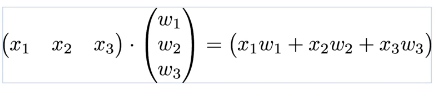
- $H(X)=XW+B$

#### 4. 행렬 연산을 고려하여 파이토치로 구현

In [100]:
x_train  =  torch.FloatTensor([[73,  80,  75],
                               [93,  88,  93],
                               [89,  91,  80],
                               [96,  98,  100],
                               [73,  66,  70]])
y_train  =  torch.FloatTensor([[152],  [185],  [180],  [196],  [142]])

In [101]:
print(x_train.shape)
print(y_train.shape)

torch.Size([5, 3])
torch.Size([5, 1])


In [103]:
# 가중치와 편향 선언
W = torch.zeros((3, 1), requires_grad=True) # W: (3,1) 벡터
b = torch.zeros(1, requires_grad=True)

In [104]:
hypothesis = x_train.matmul(W) + b

In [105]:
# 전체 코드
x_train  =  torch.FloatTensor([[73,  80,  75],
                               [93,  88,  93],
                               [89,  91,  80],
                               [96,  98,  100],
                               [73,  66,  70]])
y_train  =  torch.FloatTensor([[152],  [185],  [180],  [196],  [142]])

# 모델 초기화
W = torch.zeros((3, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
# optimizer 설정
optimizer = optim.SGD([W, b], lr=1e-5)

nb_epochs = 20
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    # 편향 b는 브로드 캐스팅되어 각 샘플에 더해집니다.
    hypothesis = x_train.matmul(W) + b

    # cost 계산
    cost = torch.mean((hypothesis - y_train) ** 2)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    print('Epoch {:4d}/{} hypothesis: {} Cost: {:.6f}'.format(
        epoch, nb_epochs, hypothesis.squeeze().detach(), cost.item()
    ))

Epoch    0/20 hypothesis: tensor([0., 0., 0., 0., 0.]) Cost: 29661.800781
Epoch    1/20 hypothesis: tensor([66.7178, 80.1701, 76.1025, 86.0194, 61.1565]) Cost: 9537.694336
Epoch    2/20 hypothesis: tensor([104.5421, 125.6208, 119.2478, 134.7862,  95.8280]) Cost: 3069.590088
Epoch    3/20 hypothesis: tensor([125.9858, 151.3882, 143.7087, 162.4333, 115.4844]) Cost: 990.670288
Epoch    4/20 hypothesis: tensor([138.1429, 165.9963, 157.5768, 178.1071, 126.6283]) Cost: 322.481873
Epoch    5/20 hypothesis: tensor([145.0350, 174.2780, 165.4395, 186.9928, 132.9461]) Cost: 107.717064
Epoch    6/20 hypothesis: tensor([148.9423, 178.9730, 169.8976, 192.0301, 136.5279]) Cost: 38.687496
Epoch    7/20 hypothesis: tensor([151.1574, 181.6346, 172.4254, 194.8856, 138.5585]) Cost: 16.499043
Epoch    8/20 hypothesis: tensor([152.4131, 183.1435, 173.8590, 196.5043, 139.7097]) Cost: 9.365656
Epoch    9/20 hypothesis: tensor([153.1250, 183.9988, 174.6723, 197.4217, 140.3625]) Cost: 7.071114
Epoch   10/20 hyp

In [106]:
# 임의의 입력 값에 대한 예측
with torch.no_grad():
    new_input = torch.FloatTensor([[75, 85, 72]])  # 예측하고 싶은 임의의 입력
    prediction = new_input.matmul(W) + b
    print('Predicted value for input {}: {}'.format(new_input.squeeze().tolist(), prediction.item()))

Predicted value for input [75.0, 85.0, 72.0]: 156.8051300048828


### **03 nn.Module과 클래스로 구현하기**
- 선형 회귀 모델 `nn.Linear()`, 평균 제곱 오차 `nn.functional.mse_loss()`와 같이 제공되는 함수를 불러와서 구현
  ```
  import torch.nn as nn
  model = nn.Linear(input_dim, output_dim)
  ```

  ```
  import torch.nn.functional as F
  cost = F.mse_loss(prediction, y_train)
  ```

#### 1. 단순 선형 회귀 구현

In [123]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [124]:
torch.manual_seed(1)

In [125]:
# 데이터
x_train = torch.FloatTensor([[1], [2], [3]])
y_train = torch.FloatTensor([[2], [4], [6]])

In [126]:
# 단순 선형 회귀 모델
model = nn.Linear(1,1)

In [127]:
print(list(model.parameters()))

[Parameter containing:
tensor([[0.5153]], requires_grad=True), Parameter containing:
tensor([-0.4414], requires_grad=True)]


In [128]:
# optimizer 설정
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [129]:
# 전체 훈련 데이터에 대해 경사 하강법을 2,000회 반복
nb_epochs = 2000
for epoch in range(nb_epochs+1):

    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    cost = F.mse_loss(prediction, y_train) # <== 파이토치에서 제공하는 평균 제곱 오차 함수

    # cost로 H(x) 개선하는 부분
    # gradient를 0으로 초기화
    optimizer.zero_grad()
    # 비용 함수를 미분하여 gradient 계산
    cost.backward() # backward 연산
    # W와 b를 업데이트
    optimizer.step()

    if epoch % 100 == 0:
    # 100번마다 로그 출력
      print('Epoch {:4d}/{} Cost: {:.6f}'.format(
          epoch, nb_epochs, cost.item()
      ))

Epoch    0/2000 Cost: 13.103541
Epoch  100/2000 Cost: 0.002791
Epoch  200/2000 Cost: 0.001724
Epoch  300/2000 Cost: 0.001066
Epoch  400/2000 Cost: 0.000658
Epoch  500/2000 Cost: 0.000407
Epoch  600/2000 Cost: 0.000251
Epoch  700/2000 Cost: 0.000155
Epoch  800/2000 Cost: 0.000096
Epoch  900/2000 Cost: 0.000059
Epoch 1000/2000 Cost: 0.000037
Epoch 1100/2000 Cost: 0.000023
Epoch 1200/2000 Cost: 0.000014
Epoch 1300/2000 Cost: 0.000009
Epoch 1400/2000 Cost: 0.000005
Epoch 1500/2000 Cost: 0.000003
Epoch 1600/2000 Cost: 0.000002
Epoch 1700/2000 Cost: 0.000001
Epoch 1800/2000 Cost: 0.000001
Epoch 1900/2000 Cost: 0.000000
Epoch 2000/2000 Cost: 0.000000


- cost값이 매우 작음

In [130]:
# 임의의 입력 4를 선언
new_var =  torch.FloatTensor([[4.0]])
# 입력한 값 4에 대해서 예측값 y를 리턴받아서 pred_y에 저장
pred_y = model(new_var) # forward 연산
# y = 2x 이므로 입력이 4라면 y가 8에 가까운 값이 나와야 제대로 학습이 된 것
print("훈련 후 입력이 4일 때의 예측값 :", pred_y)

훈련 후 입력이 4일 때의 예측값 : tensor([[7.9989]], grad_fn=<AddmmBackward0>)


- 정답 값인 8에 근접

In [131]:
print(list(model.parameters()))

[Parameter containing:
tensor([[1.9994]], requires_grad=True), Parameter containing:
tensor([0.0014], requires_grad=True)]


#### 2. 다중 선형 회귀 구현

In [117]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(1)

In [132]:
# 데이터
x_train = torch.FloatTensor([[73, 80, 75],
                             [93, 88, 93],
                             [89, 91, 90],
                             [96, 98, 100],
                             [73, 66, 70]])
y_train = torch.FloatTensor([[152], [185], [180], [196], [142]])

In [133]:
# 다중 선형 회귀 모델
model = nn.Linear(3,1)

In [134]:
print(list(model.parameters()))

[Parameter containing:
tensor([[-0.1119,  0.2710, -0.5435]], requires_grad=True), Parameter containing:
tensor([0.3462], requires_grad=True)]


In [135]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)

In [136]:
nb_epochs = 2000
for epoch in range(nb_epochs+1):

    # H(x) 계산
    prediction = model(x_train)
    # model(x_train)은 model.forward(x_train)와 동일함.

    # cost 계산
    cost = F.mse_loss(prediction, y_train) # <== 파이토치에서 제공하는 평균 제곱 오차 함수

    # cost로 H(x) 개선하는 부분
    # gradient를 0으로 초기화
    optimizer.zero_grad()
    # 비용 함수를 미분하여 gradient 계산
    cost.backward()
    # W와 b를 업데이트
    optimizer.step()

    if epoch % 100 == 0:
    # 100번마다 로그 출력
      print('Epoch {:4d}/{} Cost: {:.6f}'.format(
          epoch, nb_epochs, cost.item()
      ))

Epoch    0/2000 Cost: 42134.707031
Epoch  100/2000 Cost: 5.960053
Epoch  200/2000 Cost: 5.654707
Epoch  300/2000 Cost: 5.365413
Epoch  400/2000 Cost: 5.091429
Epoch  500/2000 Cost: 4.831834
Epoch  600/2000 Cost: 4.585997
Epoch  700/2000 Cost: 4.353045
Epoch  800/2000 Cost: 4.132426
Epoch  900/2000 Cost: 3.923438
Epoch 1000/2000 Cost: 3.725488
Epoch 1100/2000 Cost: 3.537972
Epoch 1200/2000 Cost: 3.360339
Epoch 1300/2000 Cost: 3.192076
Epoch 1400/2000 Cost: 3.032686
Epoch 1500/2000 Cost: 2.881703
Epoch 1600/2000 Cost: 2.738666
Epoch 1700/2000 Cost: 2.603199
Epoch 1800/2000 Cost: 2.474860
Epoch 1900/2000 Cost: 2.353289
Epoch 2000/2000 Cost: 2.238115


In [137]:
new_var =  torch.FloatTensor([[73, 80, 75]])
pred_y = model(new_var)
print("훈련 후 입력이 73, 80, 75일 때의 예측값 :", pred_y)

훈련 후 입력이 73, 80, 75일 때의 예측값 : tensor([[153.7184]], grad_fn=<AddmmBackward0>)


In [138]:
print(list(model.parameters()))

[Parameter containing:
tensor([[0.8541, 0.8475, 0.3096]], requires_grad=True), Parameter containing:
tensor([0.3568], requires_grad=True)]


#### 3. 모델을 클래스로 구현

In [140]:
class LinearRegressionModel(nn.Module): # torch.nn.Module을 상속받는 파이썬 클래스
    def __init__(self): #
        super().__init__()
        self.linear = nn.Linear(1, 1) # 단순 선형 회귀

    def forward(self, x):
        return self.linear(x)

In [141]:
model = LinearRegressionModel()

In [143]:
class MultivariateLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1) # 다중 선형 회귀
    def forward(self, x):
        return self.linear(x)

In [144]:
model = MultivariateLinearRegressionModel()

#### 4. 단순 선형 회귀 클래스로 구현

In [145]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(1)

In [147]:
# 데이터
x_train = torch.FloatTensor([[1], [2], [3]])
y_train = torch.FloatTensor([[2], [4], [6]])

In [148]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

In [149]:
model = LinearRegressionModel()

In [150]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [151]:
# 전체 훈련 데이터에 대해 경사 하강법을 2,000회 반복
nb_epochs = 2000
for epoch in range(nb_epochs+1):

    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    cost = F.mse_loss(prediction, y_train) # <== 파이토치에서 제공하는 평균 제곱 오차 함수

    # cost로 H(x) 개선하는 부분
    # gradient를 0으로 초기화
    optimizer.zero_grad()
    # 비용 함수를 미분하여 gradient 계산
    cost.backward() # backward 연산
    # W와 b를 업데이트
    optimizer.step()

    if epoch % 100 == 0:
    # 100번마다 로그 출력
      print('Epoch {:4d}/{} Cost: {:.6f}'.format(
          epoch, nb_epochs, cost.item()
      ))

Epoch    0/2000 Cost: 13.103541
Epoch  100/2000 Cost: 0.002791
Epoch  200/2000 Cost: 0.001724
Epoch  300/2000 Cost: 0.001066
Epoch  400/2000 Cost: 0.000658
Epoch  500/2000 Cost: 0.000407
Epoch  600/2000 Cost: 0.000251
Epoch  700/2000 Cost: 0.000155
Epoch  800/2000 Cost: 0.000096
Epoch  900/2000 Cost: 0.000059
Epoch 1000/2000 Cost: 0.000037
Epoch 1100/2000 Cost: 0.000023
Epoch 1200/2000 Cost: 0.000014
Epoch 1300/2000 Cost: 0.000009
Epoch 1400/2000 Cost: 0.000005
Epoch 1500/2000 Cost: 0.000003
Epoch 1600/2000 Cost: 0.000002
Epoch 1700/2000 Cost: 0.000001
Epoch 1800/2000 Cost: 0.000001
Epoch 1900/2000 Cost: 0.000000
Epoch 2000/2000 Cost: 0.000000


#### 5. 다중 선형 회귀 클래스로 구현

In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(1)

In [153]:
# 데이터
x_train = torch.FloatTensor([[73, 80, 75],
                             [93, 88, 93],
                             [89, 91, 90],
                             [96, 98, 100],
                             [73, 66, 70]])
y_train = torch.FloatTensor([[152], [185], [180], [196], [142]])

In [154]:
class MultivariateLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1) # 다중 선형 회귀이므로 input_dim=3, output_dim=1.

    def forward(self, x):
        return self.linear(x)

model = MultivariateLinearRegressionModel()

In [155]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)

In [156]:
nb_epochs = 2000
for epoch in range(nb_epochs+1):

    # H(x) 계산
    prediction = model(x_train)
    # model(x_train)은 model.forward(x_train)와 동일함.

    # cost 계산
    cost = F.mse_loss(prediction, y_train) # <== 파이토치에서 제공하는 평균 제곱 오차 함수

    # cost로 H(x) 개선하는 부분
    # gradient를 0으로 초기화
    optimizer.zero_grad()
    # 비용 함수를 미분하여 gradient 계산
    cost.backward()
    # W와 b를 업데이트
    optimizer.step()

    if epoch % 100 == 0:
    # 100번마다 로그 출력
      print('Epoch {:4d}/{} Cost: {:.6f}'.format(
          epoch, nb_epochs, cost.item()
      ))

Epoch    0/2000 Cost: 31667.597656
Epoch  100/2000 Cost: 0.225993
Epoch  200/2000 Cost: 0.223911
Epoch  300/2000 Cost: 0.221941
Epoch  400/2000 Cost: 0.220059
Epoch  500/2000 Cost: 0.218271
Epoch  600/2000 Cost: 0.216575
Epoch  700/2000 Cost: 0.214950
Epoch  800/2000 Cost: 0.213413
Epoch  900/2000 Cost: 0.211952
Epoch 1000/2000 Cost: 0.210560
Epoch 1100/2000 Cost: 0.209232
Epoch 1200/2000 Cost: 0.207967
Epoch 1300/2000 Cost: 0.206761
Epoch 1400/2000 Cost: 0.205619
Epoch 1500/2000 Cost: 0.204522
Epoch 1600/2000 Cost: 0.203484
Epoch 1700/2000 Cost: 0.202485
Epoch 1800/2000 Cost: 0.201542
Epoch 1900/2000 Cost: 0.200635
Epoch 2000/2000 Cost: 0.199769


### **04 미니 배치와 데이터 로더(Mini Batch and DataLoader)**

#### 1. 미니 배치와 배치 크기(Mini Batch and Batch Size)

In [157]:
x_train = torch.FloatTensor([[73, 80, 75],
                             [93, 88, 93],
                             [89, 91, 90],
                             [96, 98, 100],
                             [73, 66, 70]])
y_train = torch.FloatTensor([[152], [185], [180], [196], [142]])

- 미니 배치(Mini Batch): 전체 데이터를 더 작은 단위로 나누어서 해당 단위로 학습

  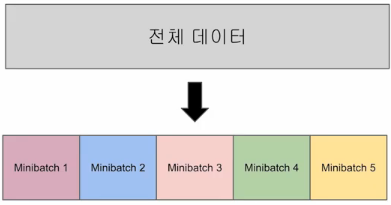
- 에포크(Epoch): 전체 훈련 데이터가 학습에 한 번 사용된 주기
- 배치 경사 하강법: 전체 데이터에 대해서 한 번에 경사 하강법을 수행하는 방법
- 미니 배치 경사 하강법: 미니 배치 단위로 경사 하강법을 수행하는 방법

#### 2. 이터레이션(Iteration)
- 에포크와 배치 크기와 이터레이션의 관계
- iteration: 한 epoch 내에서 이루어지는 매개변수의 업데이트 횟수

  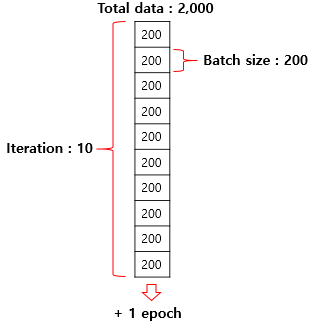

#### 3. 데이터 로드(Data Load)
- 파이토치에서 제공하는 데이터를 좀 더 쉽게 다룰 수 있도록 유용한 도구: 데이터셋(Dataset), 데이터로더(DataLoader)
  - 미니 배치 학습, 데이터 셔플, 병렬 처리를 간단히 수행
- Dataset을 정의 → DataLoader에 전달

In [158]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [159]:
from torch.utils.data import TensorDataset # 텐서데이터셋
from torch.utils.data import DataLoader # 데이터로더

In [160]:
x_train  =  torch.FloatTensor([[73,  80,  75],
                               [93,  88,  93],
                               [89,  91,  90],
                               [96,  98,  100],
                               [73,  66,  70]])
y_train  =  torch.FloatTensor([[152],  [185],  [180],  [196],  [142]])

In [161]:
dataset = TensorDataset(x_train, y_train)

In [162]:
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

- 모델이 데이터셋의 순서에 익숙해지는 것을 방지하기 위해 shuffle 사용

In [163]:
model = nn.Linear(3,1)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)

In [164]:
nb_epochs = 20
for epoch in range(nb_epochs + 1):
  for batch_idx, samples in enumerate(dataloader):
    # print(batch_idx)
    # print(samples)
    x_train, y_train = samples
    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    cost = F.mse_loss(prediction, y_train)

    # cost로 H(x) 계산
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    print('Epoch {:4d}/{} Batch {}/{} Cost: {:.6f}'.format(
        epoch, nb_epochs, batch_idx+1, len(dataloader),
        cost.item()
        ))

Epoch    0/20 Batch 1/3 Cost: 40394.078125
Epoch    0/20 Batch 2/3 Cost: 10625.847656
Epoch    0/20 Batch 3/3 Cost: 5451.569824
Epoch    1/20 Batch 1/3 Cost: 937.502686
Epoch    1/20 Batch 2/3 Cost: 265.944641
Epoch    1/20 Batch 3/3 Cost: 244.422516
Epoch    2/20 Batch 1/3 Cost: 3.523124
Epoch    2/20 Batch 2/3 Cost: 55.838848
Epoch    2/20 Batch 3/3 Cost: 2.371109
Epoch    3/20 Batch 1/3 Cost: 21.615038
Epoch    3/20 Batch 2/3 Cost: 1.536160
Epoch    3/20 Batch 3/3 Cost: 23.620941
Epoch    4/20 Batch 1/3 Cost: 12.848326
Epoch    4/20 Batch 2/3 Cost: 17.578579
Epoch    4/20 Batch 3/3 Cost: 18.382185
Epoch    5/20 Batch 1/3 Cost: 11.401794
Epoch    5/20 Batch 2/3 Cost: 20.961008
Epoch    5/20 Batch 3/3 Cost: 28.939528
Epoch    6/20 Batch 1/3 Cost: 14.807928
Epoch    6/20 Batch 2/3 Cost: 2.599214
Epoch    6/20 Batch 3/3 Cost: 33.501408
Epoch    7/20 Batch 1/3 Cost: 16.869902
Epoch    7/20 Batch 2/3 Cost: 24.529007
Epoch    7/20 Batch 3/3 Cost: 10.461083
Epoch    8/20 Batch 1/3 Cost: 8.6

In [165]:
# 임의의 입력 [73, 80, 75]를 선언
new_var =  torch.FloatTensor([[73, 80, 75]])
# 입력한 값 [73, 80, 75]에 대해서 예측값 y를 리턴받아서 pred_y에 저장
pred_y = model(new_var)
print("훈련 후 입력이 73, 80, 75일 때의 예측값 :", pred_y)

훈련 후 입력이 73, 80, 75일 때의 예측값 : tensor([[157.2804]], grad_fn=<AddmmBackward0>)


#### 4. 커스텀 데이터셋(Custom Dataset)
- torch.utils.data.Dataset을 상속받아 직접 커스텀 데이터셋(Custom Dataset)을 만드는 경우
- 기본 뼈대
```
class CustomDataset(torch.utils.data.Dataset):
  def __init__(self):
  데이터셋의 전처리를 해주는 부분

  def __len__(self):
  데이터셋의 길이. 즉, 총 샘플의 수를 적어주는 부분

  def __getitem__(self, idx):
  데이터셋에서 특정 1개의 샘플을 가져오는 함수
```

#### 5. 커스텀 데이터셋(Custom Dataset)으로 선형 회귀 구현하기

In [167]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [168]:
# Dataset 상속
class CustomDataset(Dataset):
  def __init__(self):
    self.x_data = [[73, 80, 75],
                   [93, 88, 93],
                   [89, 91, 90],
                   [96, 98, 100],
                   [73, 66, 70]]
    self.y_data = [[152], [185], [180], [196], [142]]

  # 총 데이터의 개수를 리턴
  def __len__(self):
    return len(self.x_data)

  # 인덱스를 입력받아 그에 맵핑되는 입출력 데이터를 파이토치의 Tensor 형태로 리턴
  def __getitem__(self, idx):
    x = torch.FloatTensor(self.x_data[idx])
    y = torch.FloatTensor(self.y_data[idx])
    return x, y

In [169]:
dataset = CustomDataset()
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [170]:
model = torch.nn.Linear(3,1)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)

In [171]:
nb_epochs = 20
for epoch in range(nb_epochs + 1):
  for batch_idx, samples in enumerate(dataloader):
    # print(batch_idx)
    # print(samples)
    x_train, y_train = samples
    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    cost = F.mse_loss(prediction, y_train)

    # cost로 H(x) 계산
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    print('Epoch {:4d}/{} Batch {}/{} Cost: {:.6f}'.format(
        epoch, nb_epochs, batch_idx+1, len(dataloader),
        cost.item()
        ))

Epoch    0/20 Batch 1/3 Cost: 40548.742188
Epoch    0/20 Batch 2/3 Cost: 7291.494629
Epoch    0/20 Batch 3/3 Cost: 1811.472290
Epoch    1/20 Batch 1/3 Cost: 1189.893066
Epoch    1/20 Batch 2/3 Cost: 401.466431
Epoch    1/20 Batch 3/3 Cost: 98.862206
Epoch    2/20 Batch 1/3 Cost: 59.924492
Epoch    2/20 Batch 2/3 Cost: 5.559007
Epoch    2/20 Batch 3/3 Cost: 0.005015
Epoch    3/20 Batch 1/3 Cost: 7.238708
Epoch    3/20 Batch 2/3 Cost: 0.579787
Epoch    3/20 Batch 3/3 Cost: 9.432348
Epoch    4/20 Batch 1/3 Cost: 2.596285
Epoch    4/20 Batch 2/3 Cost: 6.112614
Epoch    4/20 Batch 3/3 Cost: 0.173577
Epoch    5/20 Batch 1/3 Cost: 0.585848
Epoch    5/20 Batch 2/3 Cost: 3.764531
Epoch    5/20 Batch 3/3 Cost: 4.496256
Epoch    6/20 Batch 1/3 Cost: 1.750809
Epoch    6/20 Batch 2/3 Cost: 2.692096
Epoch    6/20 Batch 3/3 Cost: 4.092447
Epoch    7/20 Batch 1/3 Cost: 0.873122
Epoch    7/20 Batch 2/3 Cost: 3.545633
Epoch    7/20 Batch 3/3 Cost: 4.466667
Epoch    8/20 Batch 1/3 Cost: 2.943422
Epoch   

In [172]:
# 임의의 입력 [73, 80, 75]를 선언
new_var =  torch.FloatTensor([[73, 80, 75]])
# 입력한 값 [73, 80, 75]에 대해서 예측값 y를 리턴받아서 pred_y에 저장
pred_y = model(new_var)
print("훈련 후 입력이 73, 80, 75일 때의 예측값 :", pred_y)

훈련 후 입력이 73, 80, 75일 때의 예측값 : tensor([[153.5625]], grad_fn=<AddmmBackward0>)


### **05 벡터와 행렬 연산 복습하기**
1. 벡터, 행렬, 텐서
  - 벡터: 크기와 방향을 가진 양
  - 행렬: 행과 열을 가지는 2차원 형상을 가진 구조
  - 텐서: 주로 3차원 이상을 의미
2. 텐서 (Tensor)
  - Numpy를 이용한 텐서 설명

In [173]:
# 0차원 텐서(스칼라)
d = np.array(5)
print('텐서의 차원 :',d.ndim)
print('텐서의 크기(shape) :',d.shape)

텐서의 차원 : 0
텐서의 크기(shape) : ()


In [174]:
# 1차원 텐서(벡터)
d = np.array([1, 2, 3, 4])
print('텐서의 차원 :',d.ndim)
print('텐서의 크기(shape) :',d.shape)

텐서의 차원 : 1
텐서의 크기(shape) : (4,)


In [175]:
# 2차원 텐서(행렬)
# 3행 4열의 행렬
d = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print('텐서의 차원 :',d.ndim)
print('텐서의 크기(shape) :',d.shape)

텐서의 차원 : 2
텐서의 크기(shape) : (3, 4)


In [176]:
# 3차원 텐서(다차원 배열)
d = np.array([
            [[1, 2, 3, 4, 5], [6, 7, 8, 9, 10], [10, 11, 12, 13, 14]],
            [[15, 16, 17, 18, 19], [19, 20, 21, 22, 23], [23, 24, 25, 26, 27]]
            ])
print('텐서의 차원 :',d.ndim)
print('텐서의 크기(shape) :',d.shape)

텐서의 차원 : 3
텐서의 크기(shape) : (2, 3, 5)


- 그 이상의 텐서

  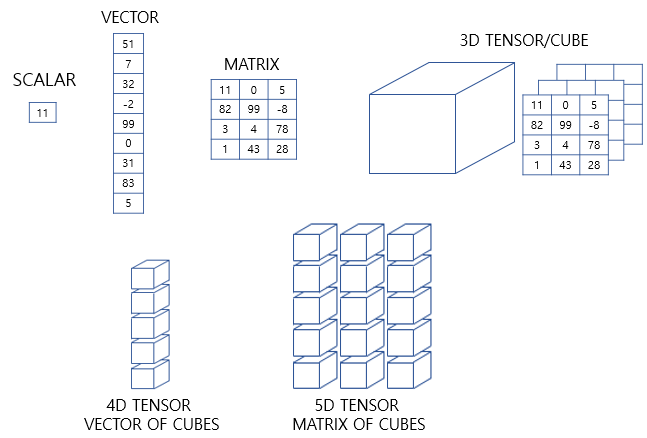

3. 벡터와 행렬의 연산

- 벡터와 행렬의 덧셈과 뺄셈

$$A + B = \left[
    \begin{array}{c}
      8 \\
      4 \\
      5 \\
    \end{array}
  \right]
+ \left[
    \begin{array}{c}
      1 \\
      2 \\
      3 \\
    \end{array}
  \right]
= \left[
    \begin{array}{c}
      9 \\
      6 \\
      8 \\
    \end{array}
  \right]$$
  
$$A - B = \left[
    \begin{array}{c}
      8 \\
      4 \\
      5 \\
    \end{array}
  \right]
- \left[
    \begin{array}{c}
      1 \\
      2 \\
      3 \\
    \end{array}
  \right]
= \left[
    \begin{array}{c}
      7 \\
      2 \\
      2 \\
    \end{array}
  \right]$$

In [177]:
A = np.array([8, 4, 5])
B = np.array([1, 2, 3])
print('두 벡터의 합 :',A+B)
print('두 벡터의 차 :',A-B)

두 벡터의 합 : [9 6 8]
두 벡터의 차 : [7 2 2]


In [178]:
# 행렬
A = np.array([[10, 20, 30, 40], [50, 60, 70, 80]])
B = np.array([[5, 6, 7, 8],[1, 2, 3, 4]])
print('두 행렬의 합 :')
print(A + B)
print('두 행렬의 차 :')
print(A - B)

두 행렬의 합 :
[[15 26 37 48]
 [51 62 73 84]]
두 행렬의 차 :
[[ 5 14 23 32]
 [49 58 67 76]]


- 벡터의 내적

$$A \cdot B =
\left[
    \begin{array}{c}
      1\ 2\ 3
    \end{array}
  \right]
\left[
    \begin{array}{c}
      4 \\
      5 \\
      6 \\
    \end{array}
  \right]
= 1 × 4 + 2 × 5 + 3 × 6 = 32\text{(스칼라)}$$

In [179]:
A = np.array([1, 2, 3])
B = np.array([4, 5, 6])
print('두 벡터의 내적 :',np.dot(A, B))

두 벡터의 내적 : 32


- 행렬의 곱셈
$$AB =
\left[
    \begin{array}{c}
      1\ 3\\
      2\ 4\\
    \end{array}
  \right]
\left[
    \begin{array}{c}
      5\ 7\\
      6\ 8\\
    \end{array}
  \right]
= \left[
    \begin{array}{c}
      1 × 5 + 3 × 6\ \ \ 1 × 7 + 3 × 8\\
      2 × 5 + 4 × 6\ \ \ 2 × 7 + 4 × 8\\
    \end{array}
  \right]
=\left[
    \begin{array}{c}
      23\ 31\\
      34\ 46\\
    \end{array}
  \right]$$

In [180]:
A = np.array([[1, 3],[2, 4]])
B = np.array([[5, 7],[6, 8]])
print('두 행렬의 행렬곱 :')
print(np.matmul(A, B))

두 행렬의 행렬곱 :
[[23 31]
 [34 46]]


#### 4. 다중 선형 회귀 행렬 연산
- 샘플의 개수가 많을 경우 행렬의 곱셈으로 표현 가능

$$\left[
    \begin{array}{c}
      w_{1}\ w_{2}\ w_{3}\ w_{4} \\
    \end{array}
  \right]
\left[
    \begin{array}{c}
      x_{11}\ x_{21}\ x_{31}\ x_{41}\ x_{51}\\
      x_{12}\ x_{22}\ x_{32}\ x_{42}\ x_{52}\\
      x_{13}\ x_{23}\ x_{33}\ x_{43}\ x_{53}\\
      x_{14}\ x_{24}\ x_{34}\ x_{44}\ x_{54}\\
    \end{array}
  \right]
+
\left[
    \begin{array}{c}
      b\ b\ b\ b\ b \\
    \end{array}
  \right]
=
\left[
    \begin{array}{c}
      y_{1}\ y_{2}\ y_{3}\ y_{4}\ y_{5} \\
    \end{array}
  \right]$$

5. 샘플(Sample)과 특성(Feature)
- 샘플: 데이터를 셀 수 있는 단위로 구분
- 특성: 종속 변수 y를 예측하기 위한 각각의 독립 변수 x

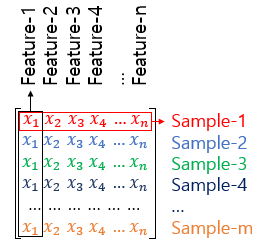

6. 가중치와 편향 행렬의 크기 결정
- 행렬 곱셈의 두 가지 조건
  1. 두 행렬의 곱 J × K이 성립되기 위해서는 행렬 J의 열의 개수와 행렬 K의 행의 개수는 같아야 한다.
  2. 두 행렬의 곱 J × K의 결과로 나온 행렬 JK의 크기는 J의 행의 개수와 K의 열의 개수를 가진다.